# AGRICULTURAL SUPPLY CHAIN ANALYSIS

- Dataset: agric_supply_chain

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Question 39. Load and inspect dataset; handle any data quality issues 

In [2]:
# explicitly create a custom list of null values that leaves out the string "None" as it is a true category in storage_type column
# load the dataset

custom_na = [" ", "N/A", "NA", "null","nan", "#N/A", "#NA", "#N/A N/A", "<N/A>", "1.#QNAN", "1.#IND", "-nan", "-NaN", "-1.#QNAN", "-1.#IND"]

df = pd.read_csv("agric_supply_chain.csv", keep_default_na=False, na_values = custom_na)

#### INSPECTING THE DATASET

In [3]:
# show first five rows of the dataset
df.head()

,record_id,farmer_id,crop,state,lga,harvest_date,season,quantity_harvested_kg,post_harvest_loss_pct,quantity_sold_kg,...,market_price_per_kg,gross_revenue_ngn,transport_mode,transport_cost_ngn,destination_market,days_to_market,storage_type,fertilizer_used,irrigation_used,cooperative_member
0,AGR-600000,FRM-04193,Pepper,Niger,Forbesborough,2022-12-29,Dry Season,26572.09,13.4,23011.43,...,1642.09,37786839.09,Rail,6700.0,Eke Awka,2,Cold Storage,No,Yes,Yes
1,AGR-600001,FRM-06299,Cassava,Anambra,Perryborough,2023-02-01,Off-Season,32172.37,5.4,30435.06,...,315.20,9593130.91,Van,8200.0,Dawanau Market,15,Silo,Yes,No,No
2,AGR-600002,FRM-07052,Pepper,Ogun,Clarktown,2023-01-10,Wet Season,15575.47,10.9,13877.74,...,1405.36,19503220.69,Motorcycle,18900.0,Wuse Market,8,Cold Storage,No,Yes,No
3,AGR-600003,FRM-01316,Pepper,Kaduna,South Micheleview,2022-01-10,Dry Season,16480.15,17.7,13563.16,...,265.98,3607529.30,Boat,13200.0,Oja Oba,16,Warehouse,No,Yes,Yes
4,AGR-600004,FRM-04837,Soybean,Ogun,Christopherberg,2023-07-05,Off-Season,36476.81,8.4,33412.76,...,780.16,26067298.84,Boat,9600.0,Oja Oba,5,None,Yes,Yes,No


In [4]:
# display shape (number of rows and columns) in the dataset
df.shape

(70000, 21)

In [5]:
# show datatypes of the columns in the dataset
df.dtypes

record_id                     str
farmer_id                     str
crop                          str
state                         str
lga                           str
harvest_date                  str
season                        str
quantity_harvested_kg     float64
post_harvest_loss_pct     float64
quantity_sold_kg          float64
farm_gate_price_per_kg    float64
market_price_per_kg       float64
gross_revenue_ngn         float64
transport_mode                str
transport_cost_ngn        float64
destination_market            str
days_to_market              int64
storage_type                  str
fertilizer_used               str
irrigation_used               str
cooperative_member            str
dtype: object

In [6]:
# display comprehensive summary of dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               70000 non-null  str    
 1   farmer_id               70000 non-null  str    
 2   crop                    70000 non-null  str    
 3   state                   70000 non-null  str    
 4   lga                     70000 non-null  str    
 5   harvest_date            70000 non-null  str    
 6   season                  70000 non-null  str    
 7   quantity_harvested_kg   70000 non-null  float64
 8   post_harvest_loss_pct   70000 non-null  float64
 9   quantity_sold_kg        70000 non-null  float64
 10  farm_gate_price_per_kg  70000 non-null  float64
 11  market_price_per_kg     70000 non-null  float64
 12  gross_revenue_ngn       70000 non-null  float64
 13  transport_mode          70000 non-null  str    
 14  transport_cost_ngn      70000 non-null  float64
 

In [7]:
# calculate and show basic statistical summary data of all numeric columns in the dataframe
df.describe()

,quantity_harvested_kg,post_harvest_loss_pct,quantity_sold_kg,farm_gate_price_per_kg,market_price_per_kg,gross_revenue_ngn,transport_cost_ngn,days_to_market
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,7.000000e+04,70000.000000,70000.000000
mean,25072.919150,18.500706,20434.653549,1025.851304,2202.573091,4.497613e+07,25479.762857,10.973443
std,14355.844621,9.513991,12012.024343,563.856863,1336.525851,4.116311e+07,14157.958569,6.060792
min,100.510000,2.000000,70.900000,50.010000,66.320000,1.705948e+04,1000.000000,1.000000
25%,12682.547500,10.300000,10213.817500,536.640000,1092.970000,1.267991e+07,13200.000000,6.000000
50%,25130.435000,18.500000,20157.695000,1023.975000,2086.120000,3.256289e+07,25600.000000,11.000000
75%,37524.092500,26.700000,30152.987500,1515.110000,3136.985000,6.621330e+07,37700.000000,16.000000
max,49999.160000,35.000000,48793.960000,2000.000000,5972.140000,2.776615e+08,50000.000000,21.000000


In [8]:
# show nulls in the dataset
df.isnull().sum()

record_id                 0
farmer_id                 0
crop                      0
state                     0
lga                       0
harvest_date              0
season                    0
quantity_harvested_kg     0
post_harvest_loss_pct     0
quantity_sold_kg          0
farm_gate_price_per_kg    0
market_price_per_kg       0
gross_revenue_ngn         0
transport_mode            0
transport_cost_ngn        0
destination_market        0
days_to_market            0
storage_type              0
fertilizer_used           0
irrigation_used           0
cooperative_member        0
dtype: int64

In [9]:
# show duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [10]:
# show empty rows in the dataset
df.isnull().all(axis=1).sum()

np.int64(0)

#### HANDLING DATA QUALITY ISSUES

In [22]:
# Convert harvest_date to datetime
df["harvest_date"] = pd.to_datetime(df["harvest_date"])

df["harvest_date"].info()

<class 'pandas.Series'>
RangeIndex: 70000 entries, 0 to 69999
Series name: harvest_date
Non-Null Count  Dtype         
--------------  -----         
70000 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 547.0 KB


## Question 40. Feature engineering: price_margin = market_price - farm_gate_price; net_profit = gross_revenue - transport_cost


In [12]:
# price margin
df["price_margin"] = df["market_price_per_kg"] - df["farm_gate_price_per_kg"]


# net profit
df["net_profit"] = df["gross_revenue_ngn"] - df["transport_cost_ngn"]


df[["price_margin","net_profit"]].head()

,price_margin,net_profit
0,794.12,37780139.09
1,100.41,9584930.91
2,481.03,19484320.69
3,140.37,3594329.30
4,402.56,26057698.84


## Question 41. Bar chart: Average post-harvest loss % by crop

''

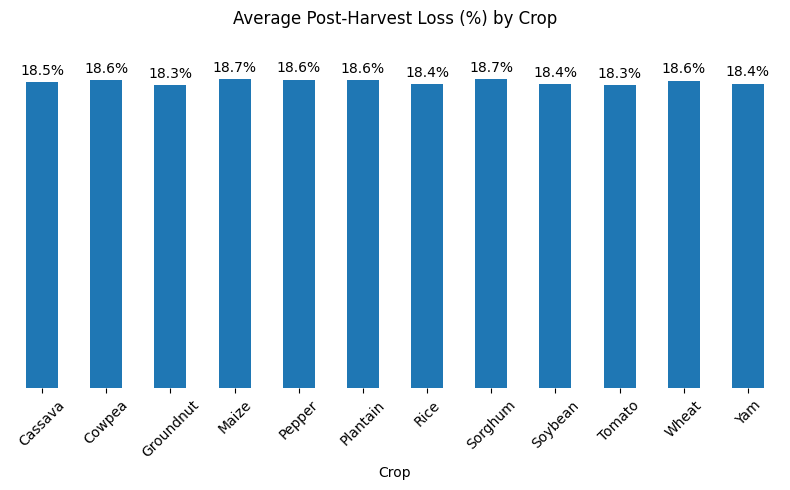

In [13]:
loss_by_crop = df.groupby("crop")["post_harvest_loss_pct"].mean()

ax = loss_by_crop.plot(kind="bar", figsize=(8,5), title="Average Post-Harvest Loss (%) by Crop")

ax.bar_label(ax.containers[0], padding=3, fmt='%.1f%%')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.set_visible(False)
ax.margins(y=0.15)

plt.xlabel("Crop")
plt.xticks(rotation=45)


plt.tight_layout()

;

## Question 42. Bar chart: Total gross revenue by state

''

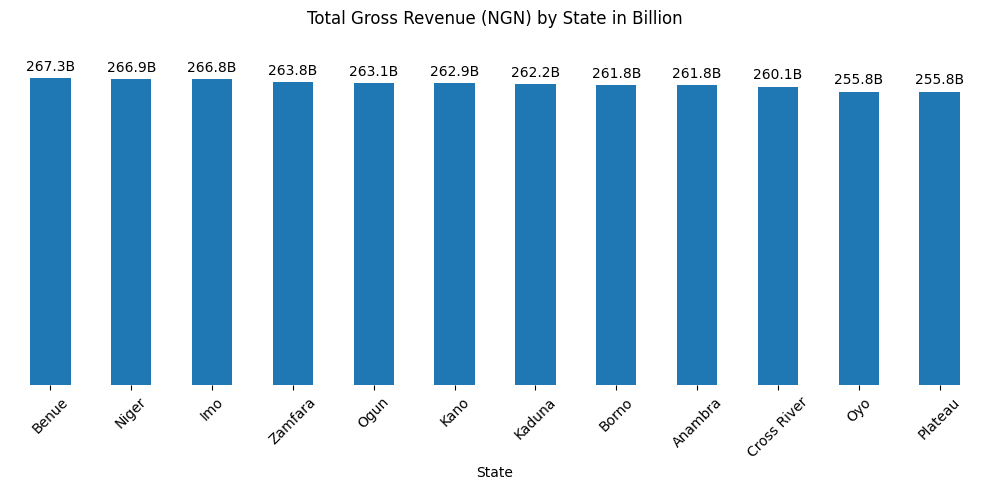

In [14]:
revenue_by_state = df.groupby("state")["gross_revenue_ngn"].sum().sort_values(ascending=False)

ax = (revenue_by_state/1e9).plot(kind="bar", figsize=(10,5), title="Total Gross Revenue (NGN) by State in Billion")

ax.bar_label(ax.containers[0], padding=3, fmt='%.1fB')

ax.yaxis.set_visible(False)
ax.margins(y=0.15)
plt.xlabel("State")
plt.xticks(rotation=45)
plt.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
;

## Question 43. Line chart: Average market price per kg by month and year

''

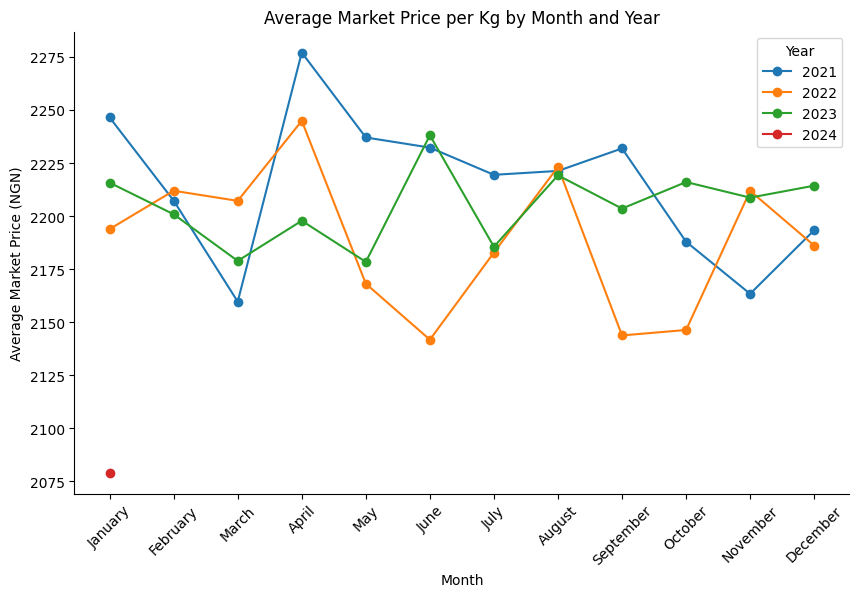

In [15]:
# extracting the year and month
df["Year"] = df["harvest_date"].dt.year
df["Month"] = df["harvest_date"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

market_price = df.groupby(["Year","Month"])["market_price_per_kg"].mean().unstack()

ax = market_price.T.plot(kind="line", figsize=(10,6), marker="o",
                    title="Average Market Price per Kg by Month and Year")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(range(12))
ax.set_xticklabels(month_order, rotation=45)

plt.xlabel("Month")
plt.ylabel("Average Market Price (NGN)")

;

## Question 44. Grouped bar: Avg post-harvest loss  cooperative members vs non-members

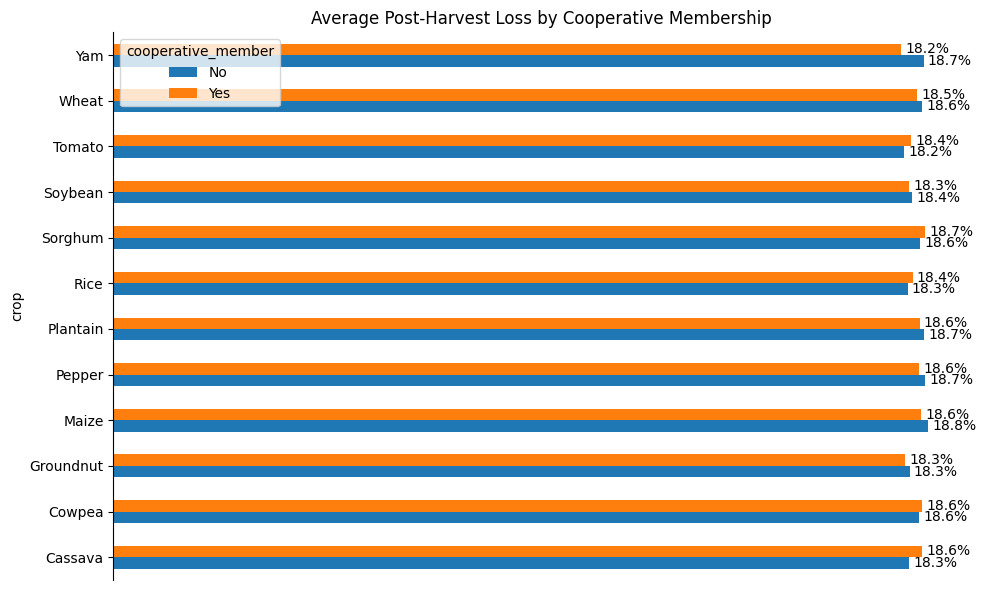

In [16]:
coop_loss = df.groupby(["crop", "cooperative_member"])["post_harvest_loss_pct"].mean().unstack()

ax = coop_loss.plot(kind="barh", figsize=(10,6), title="Average Post-Harvest Loss by Cooperative Membership")

[ax.bar_label(container, padding=3, fmt='%.1f%%') for container in ax.containers]

ax.margins(y=0.15)
ax.xaxis.set_visible(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.get_figure().tight_layout();



## Question 45. Bar chart: Transport mode vs average days to market

''

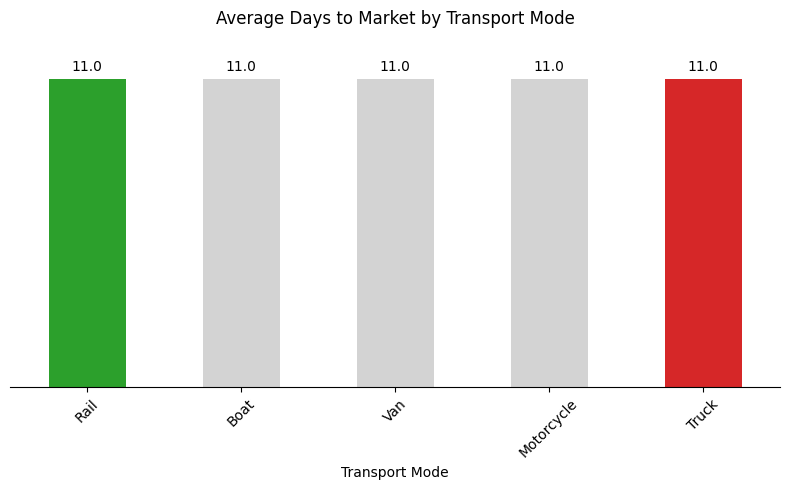

In [17]:

transport_days = round(df.groupby("transport_mode")["days_to_market"].mean().sort_values(ascending=False),0)


colors = ['#2ca02c'] + ['#d3d3d3'] * (len(transport_days) - 2) + ['#d62728']

ax = transport_days.plot(kind="bar", figsize=(8, 5), color = colors, title="Average Days to Market by Transport Mode")




ax.bar_label(ax.containers[0], padding=3, fmt='%.1f')
ax.margins(y=0.15)
ax.yaxis.set_visible(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel("Transport Mode")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.get_figure().tight_layout()

;



## Question 46. Box plot: Price margin by crop

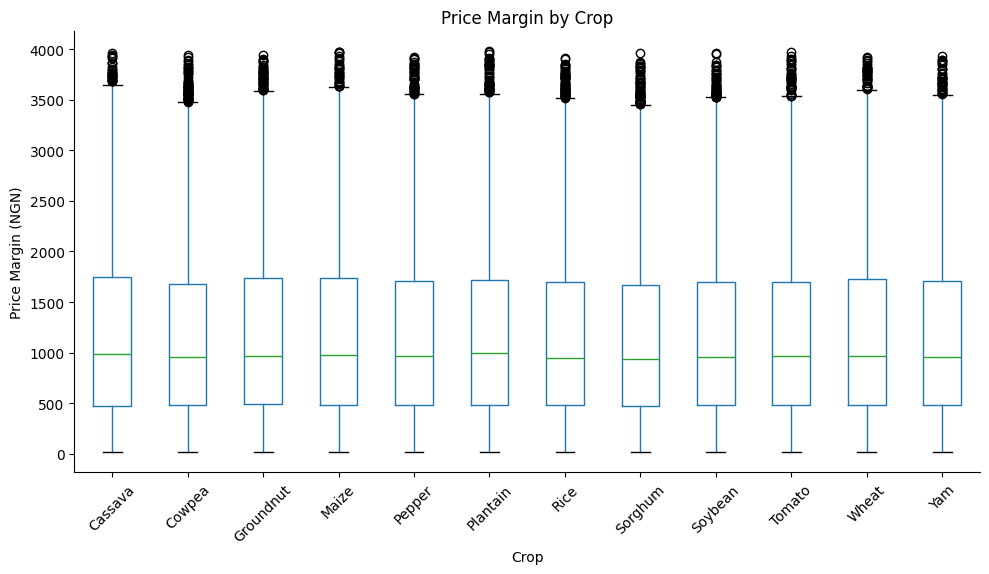

In [18]:

ax = df.boxplot(column="price_margin", by="crop", figsize=(10,6), grid = False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("Price Margin by Crop")
ax.get_figure().suptitle("") 

ax.set_xlabel("Crop")
ax.set_ylabel("Price Margin (NGN)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.get_figure().tight_layout()





## Question 47. Heatmap: Average net profit by state and crop

In [19]:
heatmap_data = df.pivot_table(values="net_profit", index="state", columns="crop", aggfunc="mean")

heatmap_data.style.background_gradient(cmap="YlGn")

crop,Cassava,Cowpea,Groundnut,Maize,Pepper,Plantain,Rice,Sorghum,Soybean,Tomato,Wheat,Yam
state,,,,,,,,,,,,
Anambra,45239007.925959,42656250.658794,44227034.691344,45958053.861688,45907622.151349,45355791.984274,46002063.942000,46314908.846735,45923730.813649,45256714.954830,43831003.842675,43778803.761611
Benue,48191103.292735,46206416.174758,46447734.556393,48996544.450291,43151276.231797,49601220.077750,45908629.625190,44468754.442550,42925733.249199,43634956.903992,42587596.609309,46986312.090966
Borno,43440429.041656,47470987.252689,43824896.990601,44480704.013866,43975120.235428,47385295.394229,45638180.440588,45308354.028531,46061625.420397,44934242.050694,44999466.642584,42229975.259365
Cross River,47141594.811123,42905577.927450,47571631.136325,46346413.125054,44848032.287659,43506513.462352,46031929.030141,43504922.870940,40717378.547741,47650721.089859,49053727.152084,45798605.579262
Imo,45555661.607388,43776671.620634,46490719.114507,42991428.965198,44763920.258295,43531570.920039,45755307.057787,42642093.614981,44655748.396262,44146136.640353,47031260.355405,45383730.458047
Kaduna,47345230.807992,45086822.444265,45392446.758104,45361576.449004,44171420.187077,44815392.082278,45415529.959686,43572130.187739,42567847.806802,44001286.788000,45166357.923760,42237337.044382
Kano,47168409.259248,46807353.409429,42061961.606355,43647523.064916,44819705.283856,44908261.926533,44747261.865385,42303866.204189,44284223.139959,44869670.341420,45693427.901151,45275433.276898
Niger,44024875.090690,45148581.246334,43477820.067231,46771792.849605,46091061.832952,46287659.909481,45513074.648598,40905105.636784,49823398.297034,44349524.669682,47109747.096561,46988284.930552
Ogun,44652541.787898,43670178.033670,47039665.344757,42987886.478843,45363781.935412,44266606.506224,42972293.146465,46987703.024181,45188965.674180,45553722.534085,45913811.946068,45216289.230855


## Question 48. Bar chart: Revenue by storage type

''

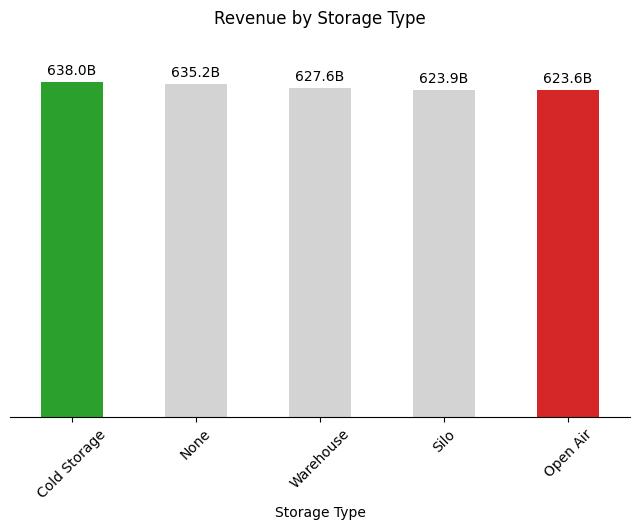

In [20]:
storage_revenue = (df.groupby("storage_type")["gross_revenue_ngn"].sum()/ 1e9).sort_values(ascending=False)

colors = ['#2ca02c'] + ['#d3d3d3'] * (len(transport_days) - 2) + ['#d62728']

ax = storage_revenue.plot(kind="bar", figsize=(8,5), color = colors, title="Revenue by Storage Type")
ax.bar_label(ax.containers[0], padding=3, fmt='%.1fB')

plt.xlabel("Storage Type")
plt.ylabel("Gross Revenue (NGN)")
plt.xticks(rotation=45)

ax.margins(y=0.15)
ax.yaxis.set_visible(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
;


## Summary: 5 supply chain improvement recommendations


1. Reduce post-harvest losses by ensuring and improving storage facilities.
2. Encourage cooperative membership among farmers.
3. Improve transportation infrastructure to reduce delays.
4. Increase access to profitable markets.
5. Train farmers on post-harvest handling and storage.